# Visualisation des frontières de kNN

Le script génère un jeu de données synthétique (en forme de demi-lunes) et trace la frontière de décision pour l'algorithme des K-Plus Proches Voisins (KNN) avec différentes valeurs de $K$. Vous pourrez ainsi observer comment la frontière passe d'une forme très complexe (surapprentissage) à une forme très lisse (sous-apprentissage) à mesure que $K$ augmente.

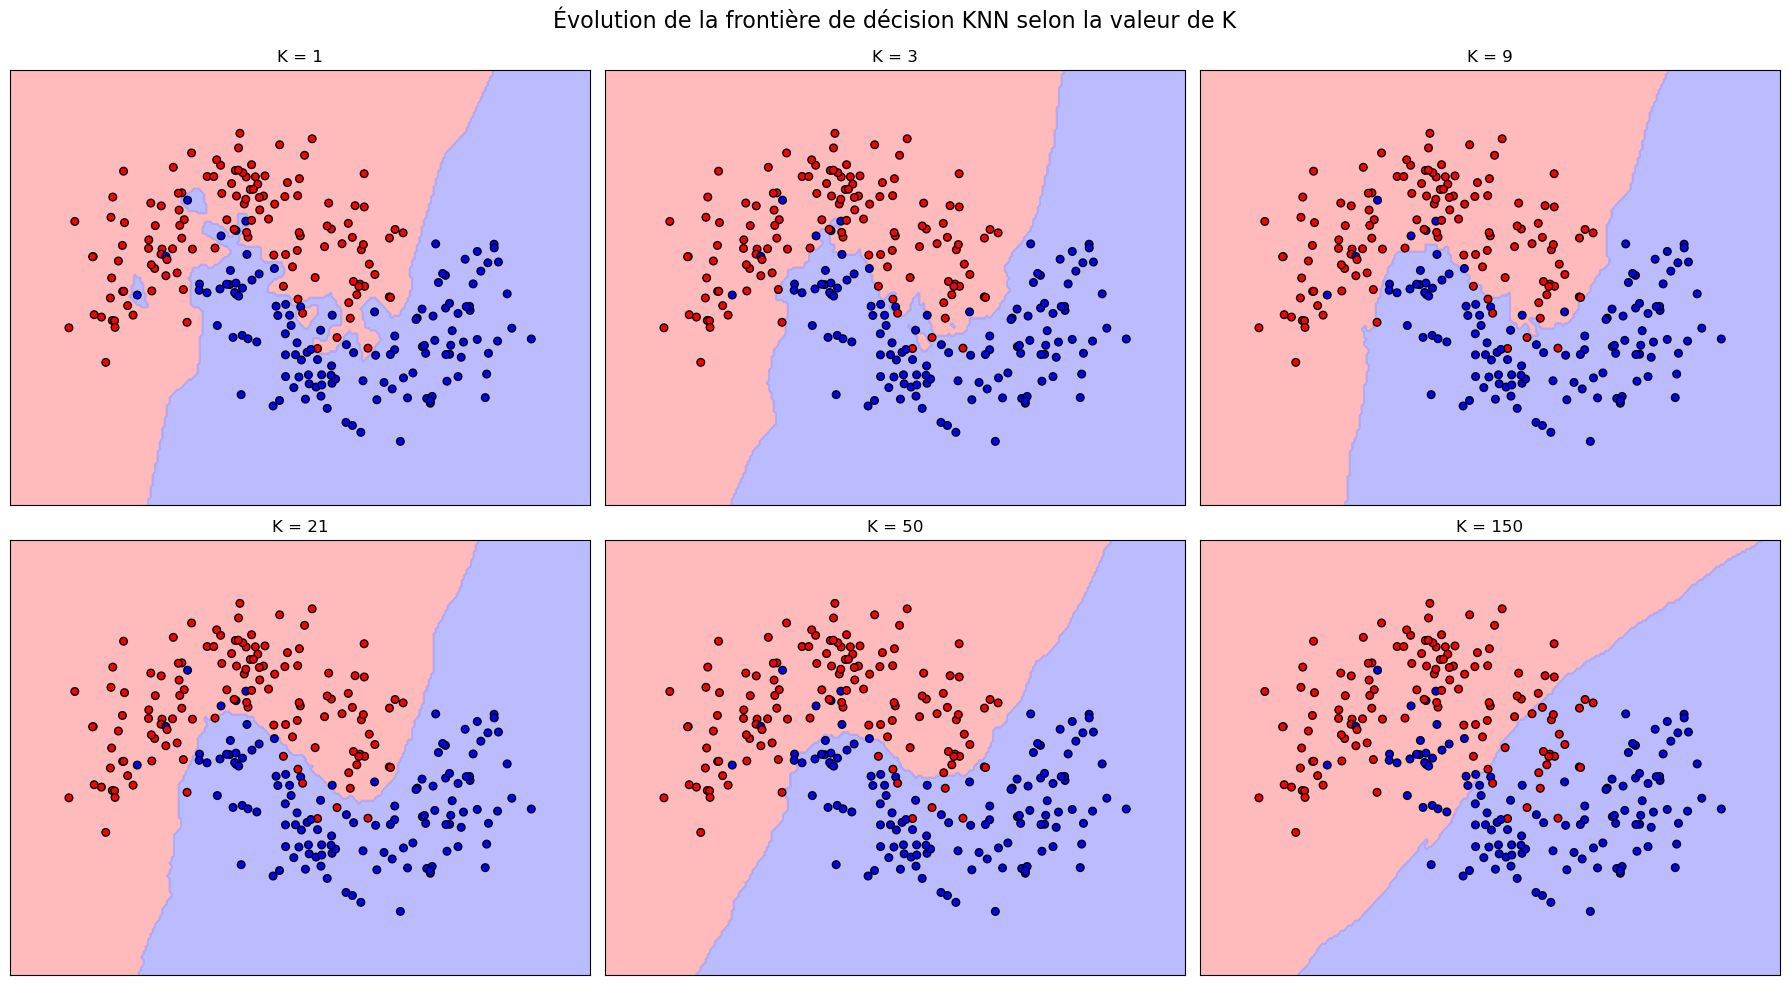

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier

# 1. Génération d'un dataset simplifié (demi-lunes avec un peu de bruit)
X, y = make_moons(n_samples=250, noise=0.25, random_state=42)

# Définition des couleurs pour le graphique
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

# 2. Préparation de la grille pour tracer les frontières de décision
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
h = 0.02  # Pas de la grille
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Valeurs de K que nous allons tester
k_values = [1, 3, 9, 21, 50, 150]

# Création de la figure (2 lignes, 3 colonnes)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Évolution de la frontière de décision KNN selon la valeur de K", fontsize=16)

# 3. Boucle sur les différentes valeurs de K
for k, ax in zip(k_values, axes.flatten()):
    # Initialisation et entraînement du modèle
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X, y)
    
    # Prédiction pour chaque point de la grille
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Tracé de la frontière de décision (fond de couleur)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    
    # Tracé des points de données réels
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=30)
    
    # Formatage du graphique
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(f"K = {k}")
    ax.set_xticks(())
    ax.set_yticks(())

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## Interprétation des résultats

Lorsque vous exécuterez ce code, vous obtiendrez une grille de 6 graphiques. Voici ce qu'il faut observer :

* **K = 1 (Surapprentissage / Overfitting) :** La frontière de décision est très découpée. Le modèle crée des îlots isolés pour capturer chaque point individuel, même les valeurs aberrantes (le bruit). Il mémorise les données d'entraînement mais généralisera mal sur de nouvelles données.
* **K = 9 à K = 21 (Bon compromis) :** La frontière devient plus douce et capture bien la tendance générale des deux classes en forme de demi-lunes, tout en ignorant le bruit local.
* **K = 150 (Sous-apprentissage / Underfitting) :** La frontière est presque une ligne droite. Le modèle prend en compte tellement de voisins qu'il est dominé par la classe majoritaire de la région. Il ne parvient plus à capturer la complexité géométrique (les courbes) du jeu de données.